# Product Popularity Classification

## Tujuan

Notebook ini bertujuan untuk membangun model klasifikasi yang mampu mengelompokkan tingkat popularitas produk berdasarkan jumlah penjualannya.

Popularitas produk dibagi menjadi tiga kategori, yaitu:

- Low
- Medium
- High

Dua algoritma klasifikasi yang digunakan pada penelitian ini adalah:

- Decision Tree Classifier
- Random Forest Classifier

Selanjutnya performa kedua model akan dibandingkan menggunakan beberapa metrik evaluasi, yaitu:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

df = pd.read_csv("../data/processed/ecommerce.csv")

df.head()

,keyword,product_id,product_name,url,currency,original_price_min,original_price_max,final_price_min,final_price_max,discount_percent,...,seller_name,seller_rating,seller_followers,seller_product,seller_response_rate,seller_response_time,seller_joined,price_avg,price_range,seller_age
0,headset,42531428335,VIVAN Earphone Headphone Headset In-Ear 3D Sub...,https://shopee.co.id/VIVAN-Earphone-Headphone-...,IDR,107000.0,107000.0,107000.0,107000.0,0,...,Vivan Official Shop,596400.0,716700.0,477.0,100.0,1,10 years ago,107000.0,0.0,10
1,headset,25117212844,Lenovo Thinkplus TH30 Headset Bluetooth V5.3 W...,https://shopee.co.id/Lenovo-Thinkplus-TH30-Hea...,IDR,240000.0,480000.0,142000.0,289000.0,53,...,Thinkplus Audio Store,56800.0,31400.0,235.0,100.0,2,33 months ago,215500.0,147000.0,33
2,headset,826361914,Xiaomi In-Ear Headphones Basic | Built-in Micr...,https://shopee.co.id/Xiaomi-In-Ear-Headphones-...,IDR,119000.0,119000.0,99000.0,99000.0,17,...,Xiaomi Official Store,3200000.0,3400000.0,341.0,95.0,2,8 years ago,99000.0,0.0,8
3,headset,40651424918,Pods Air Headset EarPods Kabel Earphone Handsf...,https://shopee.co.id/Pods-Air-Headset-EarPods-...,IDR,185165.0,185165.0,185165.0,185165.0,0,...,Pods Air,4100.0,3100.0,12.0,79.0,2,18 months ago,185165.0,0.0,18
4,headset,43662379094,Baseus Bass BH1 Lite Wireless Headphone Super ...,https://shopee.co.id/Baseus-Bass-BH1-Lite-Wire...,IDR,371420.0,371420.0,371420.0,371420.0,0,...,Baseus Official Shop,379900.0,249800.0,262.0,100.0,1,6 years ago,371420.0,0.0,6


## Membuat Target Klasifikasi

Karena dataset tidak memiliki label popularitas, maka dibuat tiga kelas berdasarkan jumlah produk terjual (sold).

Kategori yang digunakan adalah:

- Low (< 500)
- Medium (500 – 2999)
- High (≥ 3000)

In [37]:
def popularity(x):

    if x < 500:
        return "Low"

    elif x < 3000:
        return "Medium"

    else:
        return "High"

df["popularity"] = df["sold"].apply(popularity)

## Distribusi Target

Tahapan ini bertujuan untuk mengetahui keseimbangan jumlah data pada masing-masing kelas.

In [38]:
df["popularity"].value_counts()

popularity
Low       130
Medium     65
High       55
Name: count, dtype: int64

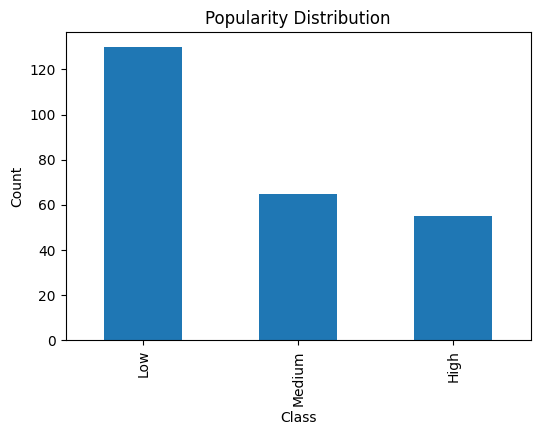

In [39]:
df["popularity"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Popularity Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

## Feature Selection

Variabel independen yang digunakan adalah:

- price_avg
- discount_percent
- rating
- review_count
- seller_followers
- seller_rating
- seller_age

Sedangkan target klasifikasi adalah popularity.

In [40]:
features = [
    "price_avg",
    "discount_percent",
    "rating",
    "review_count",
    "seller_followers",
    "seller_rating",
    "seller_age"
]

X = df[features].fillna(0)

y = df["popularity"]

## Train Test Split

Dataset dibagi menjadi:

- 80% Training Data
- 20% Testing Data

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training :", X_train.shape)

print("Testing :", X_test.shape)

Training : (200, 7)
Testing : (50, 7)


# Decision Tree Classifier

Tahapan ini membangun model menggunakan algoritma Decision Tree.

In [42]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Prediction

In [43]:
dt_pred = dt_model.predict(X_test)

## Evaluasi Model Decision Tree

In [44]:
dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print(f"Accuracy : {dt_acc:.4f}")

Accuracy : 0.9600


Decision Tree Classification Report

In [45]:
print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

        High       0.91      0.91      0.91        11
         Low       1.00      1.00      1.00        26
      Medium       0.92      0.92      0.92        13

    accuracy                           0.96        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.96      0.96      0.96        50



Decision Tree Confusion Matrix

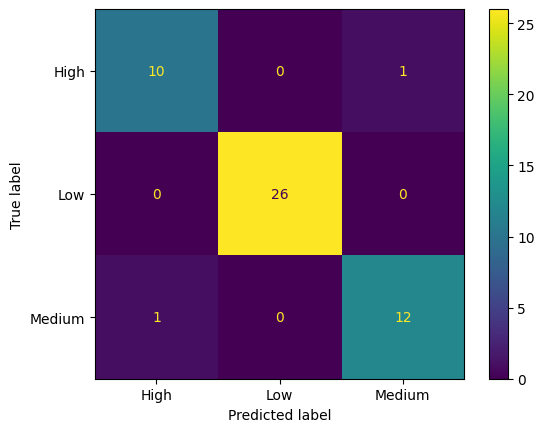

In [46]:
cm = confusion_matrix(
    y_test,
    dt_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)

disp.plot()

plt.show()

## Feature Importance

Decision Tree mampu menunjukkan fitur yang paling berpengaruh dalam proses klasifikasi.

In [47]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

dt_importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
3,review_count,0.926493
4,seller_followers,0.040759
0,price_avg,0.032749
2,rating,0.000000
1,discount_percent,0.000000
5,seller_rating,0.000000
6,seller_age,0.000000


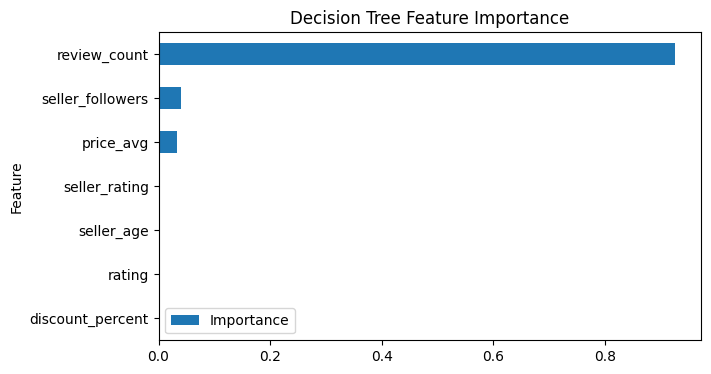

In [48]:
dt_importance.sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(7,4)
)

plt.title("Decision Tree Feature Importance")

plt.show()

# Random Forest Classifier

Tahapan ini membangun model menggunakan algoritma Random Forest.

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Random Forest Prediction

In [50]:
rf_pred = rf_model.predict(X_test)

Random Forest Accuracy

In [51]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(f"Accuracy : {rf_acc:.4f}")

Accuracy : 0.8800


Random Forest Classification Report

In [52]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

        High       0.88      0.64      0.74        11
         Low       1.00      0.96      0.98        26
      Medium       0.71      0.92      0.80        13

    accuracy                           0.88        50
   macro avg       0.86      0.84      0.84        50
weighted avg       0.90      0.88      0.88        50



Random Forest Confusion Matrix

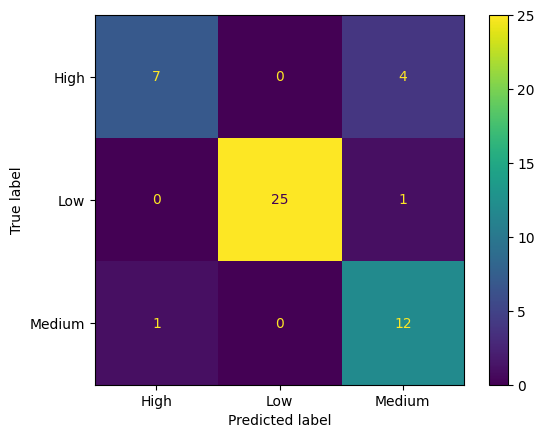

In [53]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot()

plt.show()

Random Forest Feature Importance

In [54]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
3,review_count,0.544607
0,price_avg,0.136241
5,seller_rating,0.100155
4,seller_followers,0.094962
2,rating,0.045903
1,discount_percent,0.042908
6,seller_age,0.035223


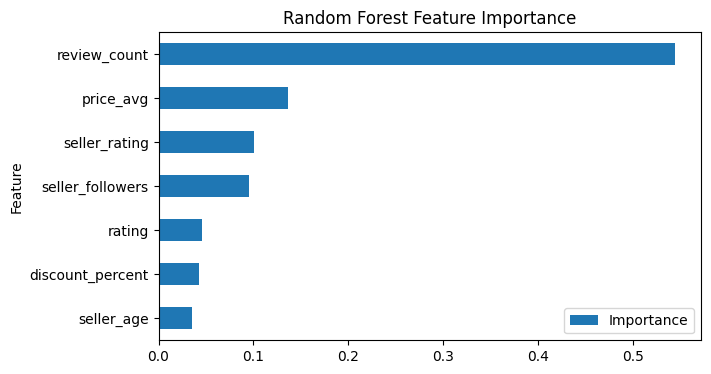

In [55]:
rf_importance.sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(7,4)
)

plt.title("Random Forest Feature Importance")

plt.show()

# Perbandingan Model

Tahapan terakhir membandingkan performa Decision Tree dan Random Forest berdasarkan nilai Accuracy.

In [56]:
comparison = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        dt_acc,
        rf_acc
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.96
1,Random Forest,0.88


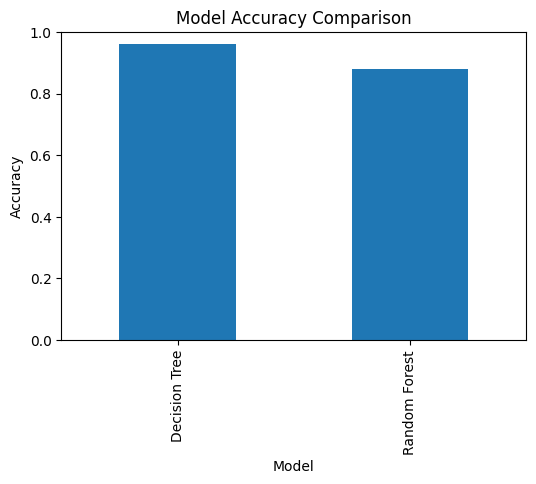

In [57]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(6,4),
    legend=False
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()